<a href="https://colab.research.google.com/github/Valrite/Digital-Image-Processing-Labs/blob/main/Lab2/Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h3>Lab 2</h3>
<p> Write a Program to read a digital image and perform the following:</p>
    <ul>
        <li>Split and display image into four quadrants – Topleft, Top Right, Bottom Left
and Bottom Right.</li>
        <li>Demonstrate rotation, scaling, and translation of an image.</li>
    </ul>

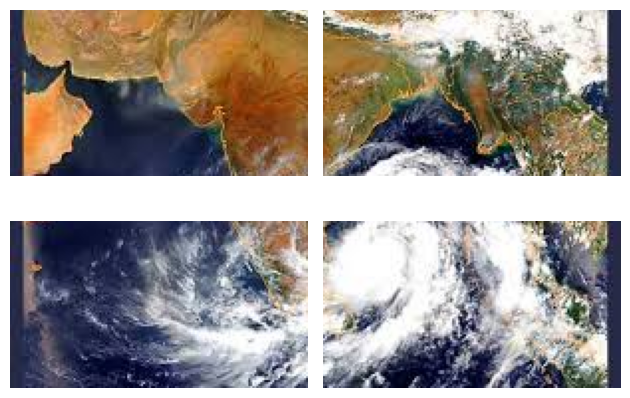

In [ ]:
# 2 a. Split and display image into four quadrants – Topleft, Top Right, Bottom Left and Bottom Right.
import cv2
import matplotlib.pyplot as plt
 # Read the image
img = cv2.imread('weather.jpeg')

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#plt.imshow(img)
#plt.axis('off')


#Split image into Topleft, Top Right, Bottom Left and Bottom Right

rows, cols, ch =img.shape
mid_row = rows//2
mid_col = cols//2

top_left = img[:mid_row,:mid_col]
top_right = img[:mid_row, mid_col:]
bottom_left =  img[mid_row:, :mid_col]
bottom_right = img[mid_row:, mid_col:]

#Display the images
fig,ax = plt.subplots(2,2)
ax[0,0].imshow(top_left)
ax[0,1].imshow(top_right)
ax[1,0].imshow(bottom_left)
ax[1,1].imshow(bottom_right)
ax[0,0].axis('off')
ax[0,1].axis('off').
ax[1,0].axis('off')
ax[1,1].axis('off')
plt.tight_layout()
plt.show()

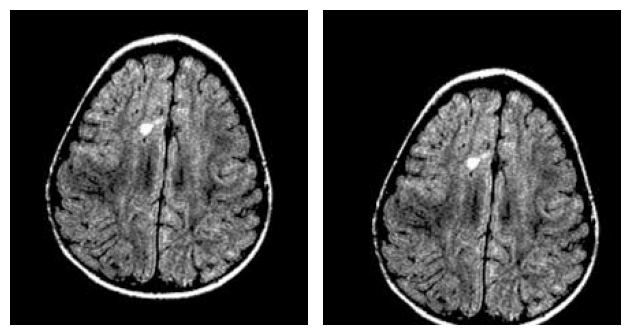

In [ ]:
# read an image
import cv2
import matplotlib.pyplot as plt
import numpy as np
im = cv2.imread("scan.jpeg")
# initialize values of tx, ty
tx = 10
ty = 25
# construct translation matrix
tm = np.float32([[1,0,tx],[0,1,ty]])
# apply translation matrix on image using warpAffine()
height = im.shape[0]
width = im.shape[1]
translated = cv2.warpAffine(im,tm,(width,height))
# display original and translated images
fig,ax = plt.subplots(1,2)
ax[0].imshow(im)
ax[1].imshow(translated)
for a in ax.ravel():
    a.axis(False)
plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(217.5), np.float64(230.5), np.float64(-0.5))

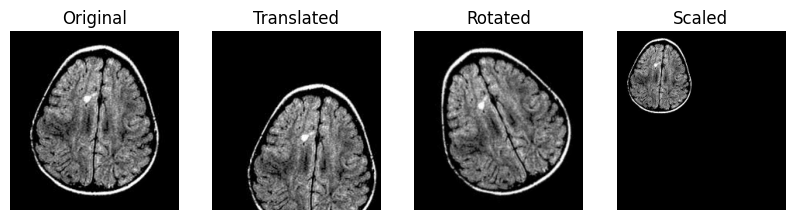

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# read an image
im = cv2.imread('scan.jpeg',0)
height, width = im.shape
#=======TRANSLATION================
tx,ty = 20,50 # initialize translation values : tx, ty
tm = np.float32([[1,0,tx],[0,1,ty]]) # construct translation matrix
# apply translation matrix on image using warpAffine()
translated = cv2.warpAffine(im, tm,(width,height))
#=======ROTATION about image center================
cx,cy = width//2,height//2 # define center coordinates
#define rotation matrix
rotation_matrix = cv2.getRotationMatrix2D( (cx,cy), angle=30, scale=1.0)
#Apply rotation matrix
rotated = cv2.warpAffine(im, rotation_matrix,(width,height))
#======SCALING======================
#define scale factor in x and y direction
s_x = 0.5
s_y = 0.5
#define scale matrix
sm = np.float32( [ [s_x, 0, 0],
[0, s_y, 0]])

#apply scale matrix
scaled = cv2.warpAffine(im, sm, (width, height))

# display original and translated images
fig,ax = plt.subplots(1,4, figsize=(10,4))
ax[0].imshow(im, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')
ax[1].imshow(translated,cmap='gray')
ax[1].set_title('Translated')
ax[1].axis('off')
ax[2].imshow(rotated, cmap='gray')
ax[2].set_title('Rotated')
ax[2].axis('off')
ax[3].imshow(scaled, cmap='gray')
ax[3].set_title('Scaled')
ax[3].axis('off')

<h2>Translating an image</h2>
<h4>Translation is the shifting of an object's location. If you know the shift in the (x,y) direction and let it be (t<sub>x</sub>,t<sub>y</sub>), you can create the transformation matrix as follows:</h4>
<img src='assets/trans.png'/>

<h4>cv2.warpAffine() is an OpenCV function used to apply an decided transformation to an image.</h4>
<code>
    translation_matrix = np.float32([[1, 0, tx], [0, 1, ty]])
    translated = cv2.warpAffine(image, translation_matrix, (width, height))
</code>
<h4>The third argument of the cv.warpAffine() function is the size of the output image, which should be in the form of (width, height). Remember width = number of columns, and height = number of rows.</h4>

<h2>Coding Practise</h2>

 <h2>Rotation of an Image using Transformation Matrix</h2>
    <p>The rotation matrix for an angle <b>θ</b> is:</p>
    <pre>
        [ cos(θ)  -sin(θ) ]
        [ sin(θ)   cos(θ) ]
    </pre>

 <h2>Rotation of an Image Around a Specific Center</h2>
    <p>The rotation matrix around a center (cx, cy) is:</p>
    <pre>
        [ cos(θ)  -sin(θ)  (1 - cos(θ)) * cx + sin(θ) * cy ]
        [ sin(θ)   cos(θ)  (1 - cos(θ)) * cy - sin(θ) * cx ]
    </pre>

<h4>To find this transformation matrix, OpenCV provides a function, cv.getRotationMatrix2D. </h4>
<code>
        rotation_matrix = cv2.getRotationMatrix2D(center, angle, scaling_factor)
        rotatedImage = cv2.warpAffine(image, rotation_matrix, (width, height))  #apply the transformation on image

</code>

<h2>Coding Exercise</h2>

<h2>Scaling an image</h2>
<h4>Scaling is just resizing of the image. OpenCV supports cv2.resize() function for this purpose
The size of the image can be specified manually, or you can specify the scaling factor. </h4>
<p></p>
<code>
height, width = img.shape[:2]
res = cv.resize(img,(2*width, 2*height), interpolation = cv.INTER_LINEAR)
</code>
<p></p>

<h2>Coding Practise</h2>